<a href="https://colab.research.google.com/github/saraplattner/2025_Intro_Python/blob/main/Feedback_SaraPlattner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feedback to Exercise W2_S2 (Replicating plots)

The exercise i found particularly challenging was the exercise from Week 2, Session 2. The exercise uses matplotlib and cartopy. The biggest challenges were issues with different projections. But also other smaller issues that made the exercise difficult for me. More details are in this feedback.

## Exercise 1: Replicating Plots using `Matplotlib` and `Numpy`
The goal here is to **replicate** the figures you see **as closely as possible**.

These instructions in exercise 1 clearly say to replicate the figures exactly the way they are displayed. However this was not always possible. More to that in Part II.

### Part I: Line and Contour Plots to Visualize Global Temperature Data


With the first part i did not have too many difficulties. But i have to say it felt a bit like a guessing game, which expression comes where. Especially the fact that the subplots (ax1 or ax2) have built-in methods for plotting for example the labels was new to me and did not come across enough in the lecture. In any other programming language that i ve come across so far (matlab and R), the labels and all these things are not methods of the subplot object.

Once i figured that out it was more or less easy.

One other thing i struggled with was the following line of code:

In [ ]:
___._______(_____,ax=___,____='$^o$C')

This line is the one that is creating the colorbar. However, the only hint i had, for knowing it should be the colorbar, was the label that should have shown "degrees Celsius". Being not very familiar with programming yet I did not recognise that these "complicated letters" should be the label for degree celsius...

### Part II: Scatter Plots to Visualize Earthquake Data


With the part II of the first exercise I had a little more difficulties, but on the whole it still went well. The next field is just to be run so that the script works afterwards. The second field after this is the initial script I had. Run it to see how my plot looked like. Below I will explain what my problems were.

In [4]:
! pip install netCDF4

# We'll need to load the data from the UNIL sharepoint using pooch, so let's
# import the library
import pooch
import numpy as np
import matplotlib.pyplot as plt

fname = pooch.retrieve(
    "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EW1bnM3elHpAtjb1KtiEw0wB9Pl5w_FwrCvVRlnilXHCtg?download=1",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

# This is the function to the set the ticks in the colorbar to be in scientific notations.
# You can directly use this function and don't need to change anything in this cell.
import matplotlib.ticker as ticker
def fmt(x, pos):
    a, b = '{:.2e}'.format(x).split('e')
    b = int(b)
    return r'$10^{{{}}}$'.format(a)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.4 MB/s eta 0:00:00


Unzipping contents of '/root/.cache/pooch/64acbefd890a7bfdd423ac258fbaa5dc-EW1bnM3elHpAtjb1KtiEw0wB9Pl5w_FwrCvVRlnilXHCtg' to '/root/.cache/pooch/64acbefd890a7bfdd423ac258fbaa5dc-EW1bnM3elHpAtjb1KtiEw0wB9Pl5w_FwrCvVRlnilXHCtg.unzip'


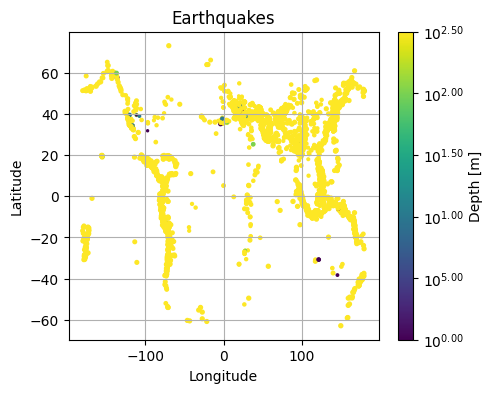

In [7]:
# Replicate the figure here
fig,ax3 = plt.subplots(1, 1, figsize=(5,4))
ctemp=ax3.scatter(longitude,latitude,s=magnitude,c=np.array(depth),marker='o',cmap='viridis',vmin=0,vmax=2.5)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth [m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')
plt.show()

As visible here, the vast majority of the data points is displayed yellow. The color should show the depth of the earthquake. And clearly not almost all the earthquakes have the same, very deep depth. So despite there being no error code, something must be wrong.
With the help of a TA i then figured out the following way to display the colors properly. The proper syntax was:

c = np.linspace(0,2.5,len(depth))

instead of:

c = np.array(depth)

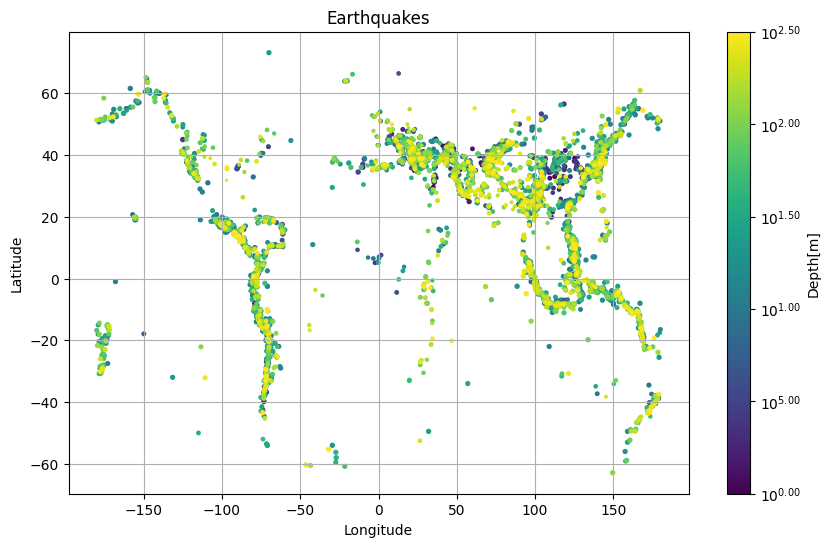

In [30]:
fig,ax3 = plt.subplots(1, 1, figsize=(10,6))
ctemp=ax3.scatter(longitude,latitude,s=magnitude, c=np.linspace(0,2.5,len(depth)),marker='o',cmap='viridis',vmin=0,vmax=2.5)

                  #c=np.array(depth),marker='o',cmap='viridis',vmin=0,vmax=2.5)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth[m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')

plt.show()

Having displayed this plot, i would actually have finished the exercise sucessfully. However I did not notice this, since the overall appearance of the colors is still different than on the example plot we had to compare our plot with.

As i mentionned above (under the title to exercise 1) it was asked of us to replicate the figures as closely as possible. It was explained to me that the differences in looks are coming from the fact that the example plot displays relative magnitude while our plot displays just the magnitude. This cannot be true since the color appearance which confused me in the first place is not connected to the magnitude but to the depth. Only after a good while of inspecting both plots for possible hints, I realised that the two plots do not even show the same number of datapoints. I noticed this, looking at the few points in the southeastern pacific. In my plot were much more points, than in the example. So either the example plot would work on a different dataset than the plot we have to do or there must be a step that reduces the number of data points. Luckily the first was not the case, otherwise my feedback would have been "it is not a very nice idea to confuse students with two different datasets that should look the same". Luckily the second was the case how i found out later.

Through conincidence while exploring the two array options that make up colorscales (displayed above) I discovered that the dataset actually contains quite a big number of NaN values. Since i am not the most agile with Python, I went the complicated way and put everything in a DataFrame in order to get rid of the NaN values, because that is the library where I know how it works.


In [47]:
import pandas as pd

df = pd.DataFrame(earthquakes)
#df.head(20)

df2 = df.iloc[:, [8, 9, 20, 21]]
#df2.head(20)

df3 = df2.dropna()
#df3.head(20)

In [48]:
depth = df3[8]
magnitude = df3[9]
latitude = df3[20]
longitude = df3[21]

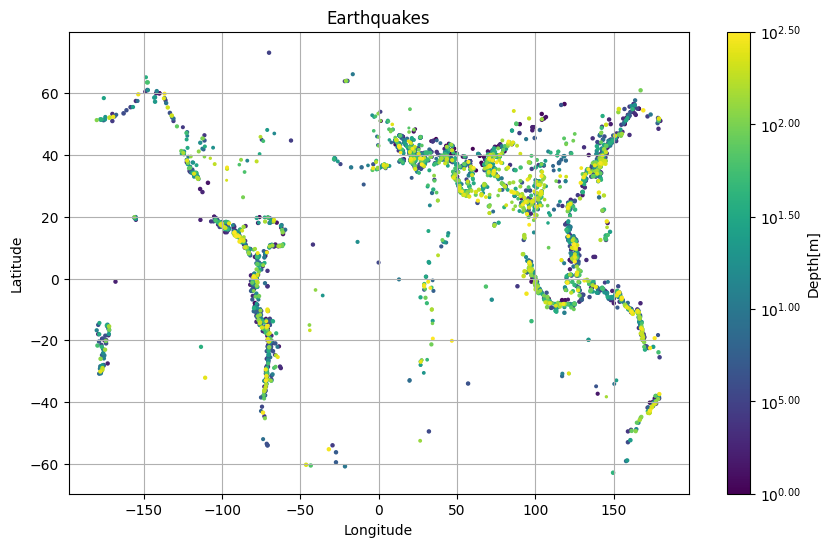

In [49]:
fig,ax3 = plt.subplots(1, 1, figsize=(10,6))
ctemp=ax3.scatter(longitude,latitude,s=magnitude/min(magnitude), c=np.linspace(0,2.5,len(depth)),marker='o',cmap='viridis',vmin=0,vmax=2.5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth[m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')

plt.show()

Now that the NaN values were all deleted, the plot looks much more similar to the example plot than the ones before. I also computed the relative magnitude, to make it look even more similar. Now there s only the color scale that still looks a bit odd. In the following plot I will try use logspace instead of linspace.

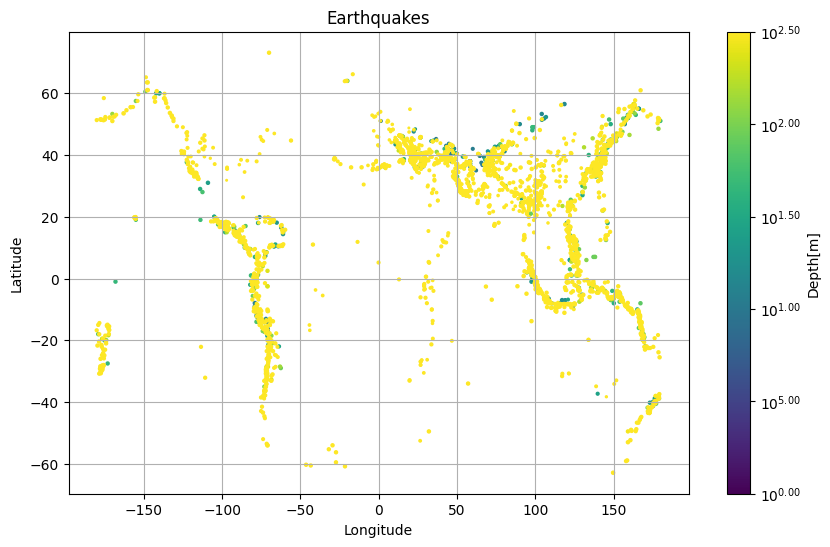

In [50]:
fig,ax3 = plt.subplots(1, 1, figsize=(10,6))
ctemp=ax3.scatter(longitude,latitude,s=magnitude/min(magnitude), c=np.logspace(0,2.5,len(depth)),marker='o',cmap='viridis',vmin=0,vmax=2.5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth[m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')

plt.show()

This was clearly not a success. It looks again more like my first plot. I now ran out of ideas how to make the plot still look more similar to the example. I will call the plot before this one my final solution of this part of the exercise.

I want to add that maybe mentionning something in the explanation about dropping the NaN values would have been really helpful. It was more a coincidence that i discovered that it could be an issue of NaN values. I would have never found the solution by "just thinking about it" because since the points were still displayed on the plot I would not have assumed that they contain a NaN value. A little hint towards that would have been helpful and appreciated.

## Exercise 2: Cartopy


### Part I: Antarctic Sea Ice


The first thing that confused me already was the line '# the rest doesnt change' in the script. I never found out which rest it was talked about, that never changes...

again the next field is just to import a lot of stuff, in order to make the scripts work...

In [51]:
!pip install --no-binary 'shapely==1.6.4' 'shapely==1.6.4' --force
!pip install cartopy

import pooch
import cartopy
import cartopy.crs as ccrs
#import xarray as xr
from netCDF4 import Dataset
######################################################################################################################################################
# Download Sea Ice files
url1 = "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EREWA38Rs-FFslQd4yKZBAsBF8m9yLzeJKEAN5gSz7LLFw?download=1"
fname1 = pooch.retrieve(url1, known_hash='1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7')
url2 = "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/Ea_2umrDTkhCrN--th4nuokBMcnVlxGshiyUq2eSpvhlTQ?download=1"
fname2 = pooch.retrieve(url2, known_hash='309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66')
######################################################################################################################################################
# Run these as is. We are reading the sea ice concentration values from our files
seaice1,seaice2 = Dataset(fname1,'r'),Dataset(fname2,'r')
var_toplot1,var_toplot2 = seaice1.variables['seaice_conc_cdr'][:],seaice2.variables['seaice_conc_cdr'][:]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for shapely: filename=Shapely-1.6.4-py2.py3-none-any.whl size=155973 sha256=09117698bac281b11fb2a9521f16a41f35cf6044bc4ba6ee9a6d1d183a92fd20
  Stored in directory: /root/.cache/pip/wheels/04/48/f8/49eb7815e85eaf1ec42a8acdf38f1266b27eaedbcf527db25d
Successfully built shapely
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libpysal 4.13.0 requires shapely>=2.0.1, but you have shapely 1.6.4 which is incompatible.
geopandas 1.1.1 requires shapely>=2.0.0, but you have shapely 1.6.4 which is incompatible.
bigframes 2.24.0 requires shapely>=1.8.5, but you have shapely 1.6.4 which